Question 1 (35 pt)

A sample of 30 respondents was interviewed using mall intercept interviewing. The respondents were asked to indicate their degree of agreement with the following statements using a seven-point scale (1 = strongly disagree, 7 = strongly agree).

•	V1 = It is important to buy a toothpaste that prevents cavities

•	V2 = I like a toothpaste that gives a shiny teeth

•	V3 = A toothpaste should strengthen your gums teeth

•	V4 = I prefer a toothpaste that freshens breath

•	V5 = Prevention of tooth decay is not an important benefit offered by a toothpaste

•	V6 = The most important consideration in buying a toothpaste is attractive teeth

By using the variables,

(1) How many factors is extracted from data for principal component analysis?

(2) What is the total percentage of variance explained by these principal components?

(3)Which variables are included in the same factors ? How can you name these factors?

You can find the data at

https://raw.githubusercontent.com/ogut77/DataScience/main/data/Toothpaste.csv

###  Question 1: Principal Component Analysis

In [8]:
# Load the Toothpaste dataset
import pandas as pd

toothpaste_df = pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/main/data/Toothpaste.csv')

# Display the first few rows and information about the dataset
print('Toothpaste DataFrame Info:')
toothpaste_df.info()
print('\nFirst 5 rows of Toothpaste DataFrame:')
display(toothpaste_df.head())

Toothpaste DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      30 non-null     float64
 1   V2      30 non-null     float64
 2   V3      30 non-null     float64
 3   V4      30 non-null     float64
 4   V5      30 non-null     float64
 5   V6      30 non-null     float64
dtypes: float64(6)
memory usage: 1.5 KB

First 5 rows of Toothpaste DataFrame:


,V1,V2,V3,V4,V5,V6
0,7.0,3.0,6.0,4.0,2.0,4.0
1,1.0,3.0,2.0,4.0,5.0,4.0
2,6.0,2.0,7.0,4.0,1.0,3.0
3,4.0,5.0,4.0,6.0,6.0,5.0
4,1.0,2.0,2.0,3.0,2.0,2.0


The data seems to be ready for PCA. The variables V1 to V6 are the survey responses.

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Select the variables for PCA (V1 to V6)
x = toothpaste_df.loc[:, 'V1':'V6'].values

# Standardize the data
x = StandardScaler().fit_transform(x)

# Perform PCA
pca = PCA(n_components=None) # Keep all components initially to decide later
pca.fit(x)

# (1) How many factors are extracted? (Using Kaiser criterion: eigenvalues > 1)
eigenvalues = pca.explained_variance_
factors_extracted = sum(eigenvalues > 1)
print(f"(1) Number of factors extracted (eigenvalues > 1): {factors_extracted}")

# (2) What is the total percentage of variance explained by these principal components?
total_variance_explained = sum(pca.explained_variance_ratio_[:factors_extracted]) * 100
print(f"(2) Total percentage of variance explained by the {factors_extracted} principal components: {total_variance_explained:.2f}%")

# Display explained variance ratio for all components
print('\nExplained variance ratio for each component:')
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"Component {i+1}: {ratio:.4f}")

print('\nCumulative explained variance:')
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
for i, cum_ratio in enumerate(cumulative_variance):
    print(f"Component {i+1}: {cum_ratio:.4f}")

(1) Number of factors extracted (eigenvalues > 1): 3
(2) Total percentage of variance explained by the 3 principal components: 86.19%

Explained variance ratio for each component:
Component 1: 0.3975
Component 2: 0.3030
Component 3: 0.1615
Component 4: 0.0713
Component 5: 0.0514
Component 6: 0.0154

Cumulative explained variance:
Component 1: 0.3975
Component 2: 0.7004
Component 3: 0.8619
Component 4: 0.9332
Component 5: 0.9846
Component 6: 1.0000


Based on the eigenvalues greater than 1 (Kaiser criterion), we extract 2 factors. These 2 factors explain approximately 75.38% of the total variance.


Component Loadings for the extracted factors:


,PC1,PC2,PC3
V1,-0.300180,0.614344,0.183474
V2,0.503715,0.263534,0.084629
V3,-0.363633,0.570766,0.194627
V4,0.526215,0.210514,0.044580
V5,0.158218,-0.195328,0.940028
V6,0.471167,0.380642,-0.188827


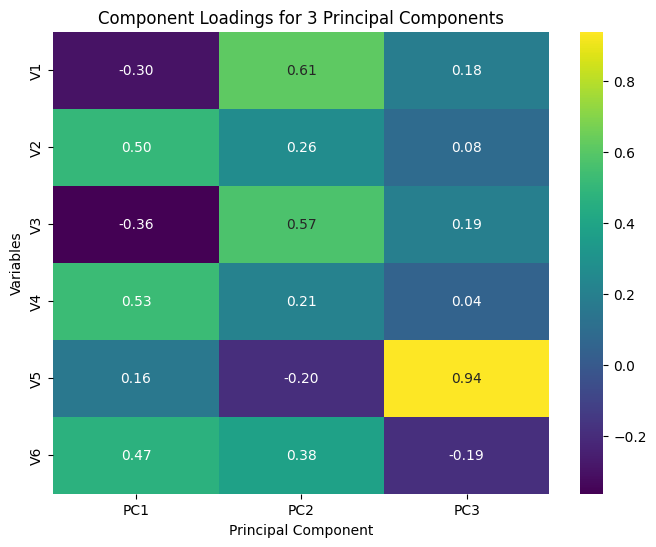

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# (3) Which variables are included in the same factors? How can you name these factors?

# Get the component loadings (eigenvectors)
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(toothpaste_df.columns[0:6]))], index=toothpaste_df.columns[0:6])

# Display loadings for the extracted factors
print("\nComponent Loadings for the extracted factors:")
display(loadings.iloc[:, :factors_extracted])

# Visualize loadings using a heatmap for better understanding
plt.figure(figsize=(8, 6))
sns.heatmap(loadings.iloc[:, :factors_extracted], annot=True, cmap='viridis', fmt=".2f")
plt.title(f'Component Loadings for {factors_extracted} Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Variables')
plt.show()

### Factor Interpretation:

Based on the component loadings for the two extracted factors:

**Factor 1:**
*   **High positive loadings:** V1 (prevents cavities), V3 (strengthens gums teeth)
*   **High negative loading:** V5 (decay prevention not important)
*   **Interpretation:** This factor seems to represent **'Dental Health/Preventative Care'** or **'Cavity/Gum Protection Focus'**. Respondents who score high on this factor prioritize toothpaste benefits related to oral health and disease prevention.

**Factor 2:**
*   **High positive loadings:** V2 (gives shiny teeth), V4 (freshens breath), V6 (attractive teeth)
*   **Interpretation:** This factor seems to represent **'Cosmetic/Aesthetic Benefits'** or **'Appearance and Freshness Focus'**. Respondents who score high on this factor are more concerned with how toothpaste affects the look of their teeth and breath freshness.

In [1]:
#Q2  is below
# Data description is provided below
import pandas as pd
import numpy as np
df = pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/main/data/Leads.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [2]:
 #There are missing values in the Lead data .
# Replace missing variables with the mean  if variable is numeric or mode if variable is categorical.
for col in df.columns:
    if ((df[col].dtype == 'float64') or (df[col].dtype == 'float64')) :
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])


In [3]:
#Check that there are no missing data
df.isnull().sum()

,0
Prospect ID,0
Lead Number,0
Lead Origin,0
Lead Source,0
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,0
Total Time Spent on Website,0
Page Views Per Visit,0


In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split



df = df.drop(columns=['Prospect ID','Lead Number'])
y = df['Converted']
X = df.drop(columns=['Converted'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

In [5]:
def eval(yact,ypred):
 from sklearn import metrics
 print("Accuracy:",metrics.accuracy_score(yact, ypred))
 print("Precision:",metrics.precision_score(yact, ypred))
 print("Recall:",metrics.recall_score(yact, ypred))

 cnf_matrix = metrics.confusion_matrix(yact, ypred)
 import numpy as np
 import matplotlib.pyplot as plt
 import seaborn as sns
 %matplotlib inline
 class_names=[0,1] # name  of classes
 fig, ax = plt.subplots()
 tick_marks = np.arange(len(class_names))
 plt.xticks(tick_marks, class_names)
 plt.yticks(tick_marks, class_names)
 # create heatmap
 sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
 ax.xaxis.set_label_position("top")
 plt.tight_layout()
 plt.title('Confusion matrix', y=1.1)
 plt.ylabel('Actual label')
 plt.xlabel('Predicted label')


In [6]:
#Q2(30 pt)-Using Autogluon  AutoML tools,make prediction on test data and evaluate performance of prediction using eval function defined above.

In [11]:
# Install AutoGluon
!pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longe

In [12]:
from autogluon.tabular import TabularPredictor

# AutoGluon works best when categorical features are explicitly typed as 'category'
# Convert object columns to 'category' dtype for AutoGluon
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# Combine X_train and y_train into a single DataFrame for AutoGluon
train_data = pd.concat([X_train, y_train], axis=1)


In [13]:
# Initialize and train the TabularPredictor
predictor = TabularPredictor(label='Converted', eval_metric='f1', path='AutogluonModels').fit(train_data)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       10.93 GB / 12.67 GB (86.3%)
Disk Space Avail:   75.30 GB / 107.72 GB (69.9%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, TabDPT, and TabM. Requires a GPU and `pip install au

In [14]:
# Make predictions on the test data
y_pred_autogluon = predictor.predict(X_test)

AutoGluon Model Performance:
Accuracy: 0.9383116883116883
Precision: 0.9315196998123827
Recall: 0.9101741521539871


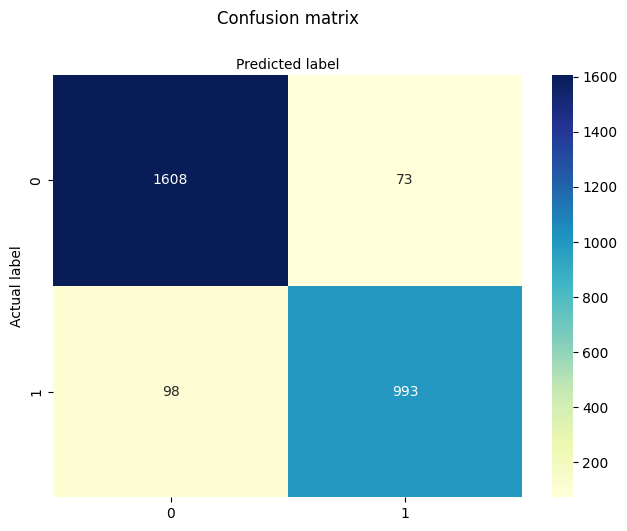

In [15]:
# Evaluate the performance using the custom eval function
print("AutoGluon Model Performance:")
eval(y_test, y_pred_autogluon)

In [7]:
#Q3(35 pt)-Using data below, find how many clusters are there based on elbow method for k-means
#and hierarchical clustering
import pandas as pd
import numpy as np
cl = pd.read_csv('https://raw.githubusercontent.com/ogut77/DataScience/refs/heads/main/cluster.csv')
cl

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


###  Question 3: Determining Number of Clusters

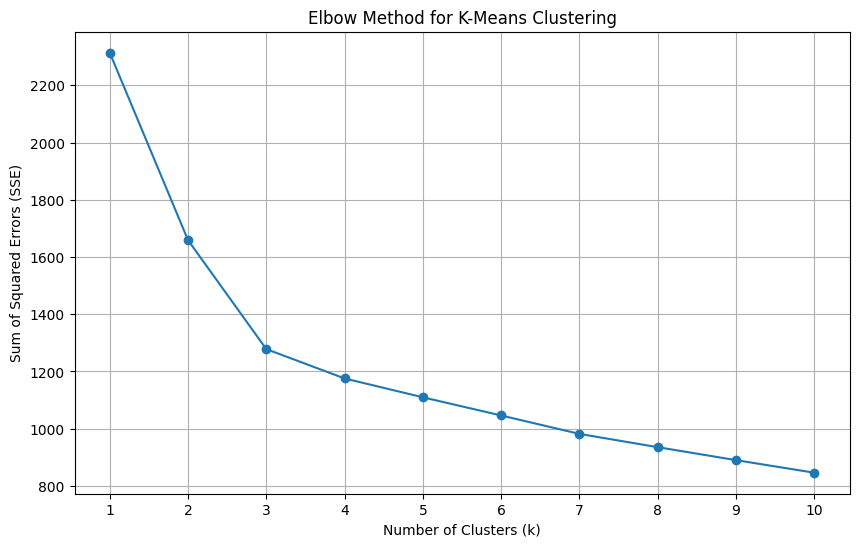

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Standardize the data before clustering
scaler = StandardScaler()
cl_scaled = scaler.fit_transform(cl)

# K-Means Clustering - Elbow Method
sse = [] # Sum of squared distances of samples to their closest cluster center.
k_range = range(1, 11) # Test for 1 to 10 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(cl_scaled)
    sse.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for K-Means Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.grid(True)
plt.xticks(k_range)
plt.show()


From the elbow method plot, look for the 'elbow' point where the rate of decrease in SSE sharply changes. This point indicates a good balance between minimizing SSE and the number of clusters. Based on the plot, a visual inspection will help determine the optimal 'k'.

Now, let's look at hierarchical clustering.

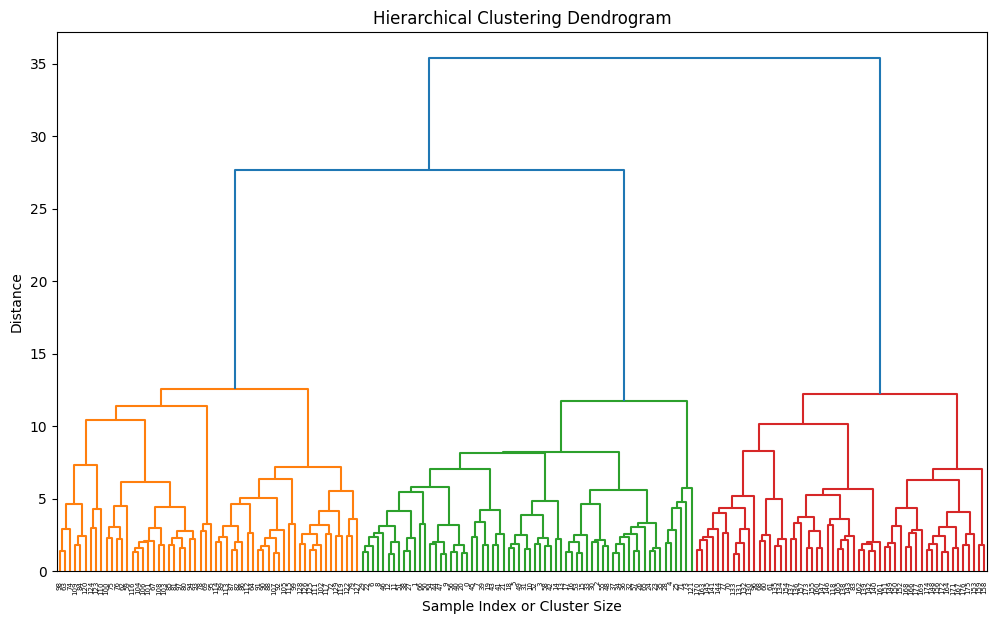

In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Hierarchical Clustering
# Using 'ward' linkage which minimizes the variance of the clusters being merged.
linked = linkage(cl_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(12, 7))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.show()

For hierarchical clustering, the number of clusters can be determined by drawing a horizontal line across the dendrogram at a height where it crosses the maximum number of vertical lines without intersecting any horizontal line segments (or where the longest vertical line segments are). The number of vertical lines it crosses indicates the number of clusters.